In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [30]:
df = sns.load_dataset('titanic')

df['family'] = df['sibsp'] + df['parch']

df = df[['age', 'fare', 'family', 'survived']]

df.head()

,age,fare,family,survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       714 non-null    float64
 1   fare      891 non-null    float64
 2   family    891 non-null    int64  
 3   survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


### Applying pandas for handling missing data 

In [19]:
df.isnull().sum()

age         177
fare          0
family        0
survived      0
dtype: int64

In [32]:
X = df[['age', 'fare', 'family']]
y = df['survived']

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2,random_state=2)

In [25]:
X_train.shape, X_test.shape

((712, 3), (179, 3))

In [26]:
X_train.isnull().sum()

age       148
fare        0
family      0
dtype: int64

In [27]:
mean_age = X_train['age'].mean()
median_age = X_train['age'].median()

In [ ]:
X_train['age_median'] = X_train['age'].fillna(median_age)
X_train['age_mean'] = X_train['age'].fillna(mean_age)

In [29]:
X_train.sample(5)

,age,fare,family,age_median,age_mean
647,56.0,35.5000,0,56.0,56.0
482,50.0,8.0500,0,50.0,50.0
582,54.0,26.0000,0,54.0,54.0
811,39.0,24.1500,0,39.0,39.0
701,35.0,26.2875,0,35.0,35.0


In [ ]:
print('Original age variable variance: ', X_train['age'].var())
print('Age variance after median imputation: ', X_train['age_median'].var())
print('Age variance after mean imputation: ', X_train['age_mean'].var())

Original age variable variance:  204.34951339046142
Age variance after median imputation:  161.98956633460548
Age variance after mean imputation:  161.81262452718676


findfont: Failed to find font weight normal, now using 700.


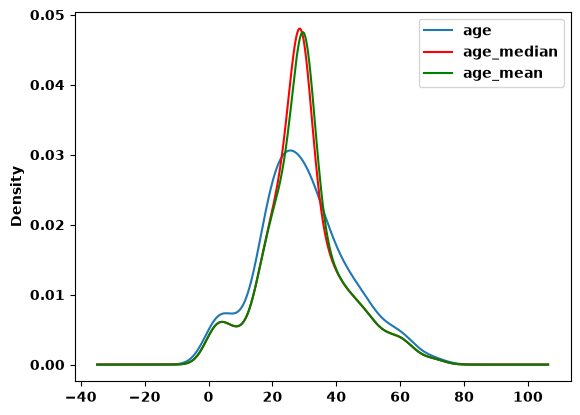

In [31]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
X_train['age'].plot(kind='kde', ax=ax)

# variable imputed with median
X_train['age_median'].plot(kind='kde', ax=ax, color='red')

# variable imputed with mean
X_train['age_mean'].plot(kind='kde', ax=ax, color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

In [32]:
X_train.cov()

,age,fare,family,age_median,age_mean
age,204.349513,71.512440,-6.498901,204.349513,204.349513
fare,71.512440,2368.246832,16.847264,58.986531,56.626587
family,-6.498901,16.847264,2.735252,-5.112563,-5.146106
age_median,204.349513,58.986531,-5.112563,161.989566,161.812625
age_mean,204.349513,56.626587,-5.146106,161.812625,161.812625


In [33]:
X_train.corr()

,age,fare,family,age_median,age_mean
age,1.000000,0.095814,-0.299113,1.000000,1.000000
fare,0.095814,1.000000,0.209323,0.095235,0.091475
family,-0.299113,0.209323,1.000000,-0.242883,-0.244610
age_median,1.000000,0.095235,-0.242883,1.000000,0.999454
age_mean,1.000000,0.091475,-0.244610,0.999454,1.000000


<Axes: >

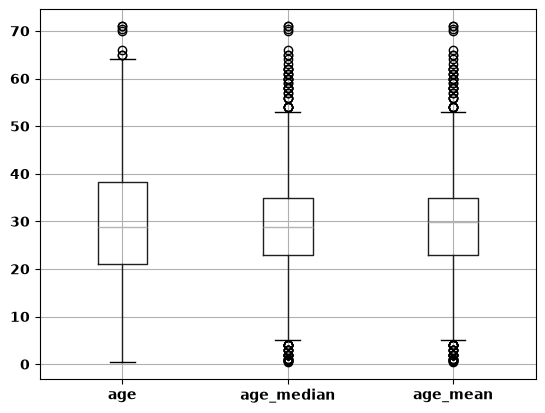

In [34]:
X_train[['age', 'age_median', 'age_mean']].boxplot()

### Using Sklearn lib for handling missing data

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2,random_state=2)

In [34]:
imputer1 = SimpleImputer(strategy='median')
imputer2 = SimpleImputer(strategy='mean')

In [35]:
trf = ColumnTransformer([
    ('imputer1', imputer1, ['age'])
],remainder='passthrough')

In [36]:
trf.fit(X_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('imputer1', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. 

In [37]:
trf.named_transformers_['imputer1'].statistics_

array([28.75])

In [38]:
X_train = trf.fit_transform(X_train)
X_test = trf.transform(X_test)

In [39]:
X_train = pd.DataFrame(X_train, columns=X.columns)
X_train

,age,fare,family
0,40.00,27.7208,0.0
1,4.00,16.7000,2.0
2,47.00,9.0000,0.0
3,9.00,31.3875,6.0
4,20.00,9.8458,0.0
...,...,...,...
707,30.00,8.6625,0.0
708,28.75,8.7125,0.0
709,71.00,49.5042,0.0
710,28.75,221.7792,0.0


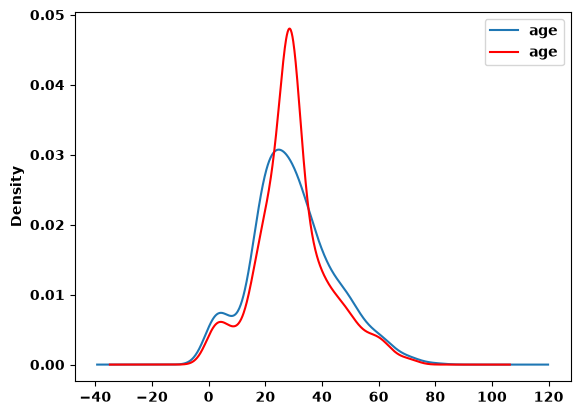

In [40]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
X['age'].plot(kind='kde', ax=ax)

# variable imputed with median
X_train['age'].plot(kind='kde', ax=ax, color='red')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

# Simple Imputer

Simple imputation is the process of replacing missing data with a single statistical value, such as the mean, median, or most frequent value, so that the dataset can be used to train a machine learning model.

Why is it needed?

Machine learning algorithms usually cannot work with missing values (NaN). Simple imputation helps by replacing those missing values with reasonable estimates.

Common methods of simple imputation

| Method                   | Used for                      | Example                                                       |
| ------------------------ | ----------------------------- | ------------------------------------------------------------- |
| **Mean**                 | Numerical data                | Replace missing salary with the average salary.               |
| **Median**               | Numerical data with outliers  | Replace missing age with the median age.                      |
| **Most Frequent (Mode)** | Categorical or numerical data | Replace missing gender with the most common value.            |
| **Constant**             | Any type of data              | Replace missing values with `0`, `"Unknown"`, or `"Missing"`. |


Advantages
- Easy to understand and implement.
- Fast and computationally inexpensive.
- Preserves all rows in the dataset.
- Works well when only a small percentage of values are missing.

Disadvantages
- Ignores relationships between features.
- Can reduce the natural variability of the data.
- May introduce bias if many values are missing.
